# TQ-IoT: Multi-Objective IoT Sensor Scheduling
## Tabular Q-Learning + Chebyshev Scalarisation on Real FIT IoT-Lab Data

**Authors:** Abhay Singh & Peeyush Kelkar  
**Stockholm University — Spring 2026**  
**Thesis:** Multi-Objective Decision Optimization for IoT Sensor Scheduling: Balancing Battery Lifetime and Age of Information

---

### Why FIT IoT-Lab real traces?
Standard RL benchmarks use fully synthetic environments. FIT IoT-Lab provides real hardware traces from physical IoT nodes — actual power draw, real sensor readings, realistic channel behaviour. Using these traces makes our results academically defensible and directly applicable to real deployments.

### Why AoI and battery form a multi-objective tradeoff
Age of Information measures how stale the data at the receiver is. Transmitting frequently keeps AoI low but drains the battery. Sleeping conserves energy but lets AoI grow. These objectives cannot be simultaneously optimised — there is no single "best" policy. A Pareto front of non-dominated policies is the correct solution concept.

### Why Chebyshev scalarisation?
Weighted-sum scalarisation cannot recover non-convex parts of the Pareto front. Chebyshev scalarisation (minimax) provably covers the entire Pareto front including non-convex regions, making it theoretically superior and more appropriate for a thesis contribution.

### Why baselines?
Baselines show what a naive engineer would deploy. TQ-IoT must outperform all of them on intermediate trade-offs to justify the complexity of multi-objective RL.

### Master-level thesis contribution
This work combines: (1) real hardware data, (2) multi-objective RL with theoretical guarantees, (3) statistical validation across seeds, (4) sensitivity and ablation analysis. Each component is independently defensible.

---

> **To run a different experiment, change only `EXPERIMENT_ID` in the next cell.**


## 1. Configuration — Change Only This Cell

In [17]:
from pathlib import Path
import os

# ══════════════════════════════════════════════════════════════════════════════
#  USER CONFIGURATION — change EXPERIMENT_ID to switch datasets
# ══════════════════════════════════════════════════════════════════════════════

EXPERIMENT_ID = 436032

# ── derived paths (do not edit) ───────────────────────────────────────────────
# works whether you run from notebooks/ or from the project root
_notebook_dir = Path.cwd()
_project_root = _notebook_dir.parent if _notebook_dir.name == "notebooks" else _notebook_dir

RAW_DATA_DIR  = _project_root / "data" / "raw"  / f"exp_{EXPERIMENT_ID}"
RESULTS_DIR   = _project_root / "results"        / f"exp_{EXPERIMENT_ID}"
FIGURES_DIR   = RESULTS_DIR   / "figures"

# ── create output folders ─────────────────────────────────────────────────────
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR.parent.parent / "data" / "processed").mkdir(parents=True, exist_ok=True)

# ── validate input folder ─────────────────────────────────────────────────────
if not RAW_DATA_DIR.exists():
    raise FileNotFoundError(
        f"Raw data folder not found: {RAW_DATA_DIR}\n"
        f"Please create it and add your FIT IoT-Lab files."
    )

# ── detect available sub-folders ─────────────────────────────────────────────
SUBFOLDERS = ["consumption", "log", "radio", "sniffer", "event"]
available  = {s: (RAW_DATA_DIR / s).exists() and
                 any((RAW_DATA_DIR / s).iterdir())
              for s in SUBFOLDERS
              if (RAW_DATA_DIR / s).exists()}

print(f"Experiment ID  : {EXPERIMENT_ID}")
print(f"Raw data dir   : {RAW_DATA_DIR}")
print(f"Results dir    : {RESULTS_DIR}")
print(f"Available data : {list(available.keys())}")

# ── RL / experiment settings (change if needed) ───────────────────────────────
SEEDS                = list(range(10))          # 10 seeds for statistical validation
EPISODES_PER_WEIGHT  = 100                      # training episodes per weight config
EVAL_EPISODES        = 50                       # evaluation episodes per policy
AOI_CAP              = 20                       # maximum AoI
BATTERY_CAP          = 100                      # battery units
AOI_STALE_THRESHOLD  = 10                       # AoI > this = stale

WEIGHTS = [                                     # (wE, wF) preference pairs
    (0.0, 1.0), (0.1, 0.9), (0.2, 0.8),
    (0.3, 0.7), (0.4, 0.6), (0.5, 0.5),
    (0.6, 0.4), (0.7, 0.3), (0.8, 0.2),
    (0.9, 0.1), (1.0, 0.0),
]

print(f"Seeds          : {SEEDS}")
print(f"Weight configs : {len(WEIGHTS)}")


Experiment ID  : 436032
Raw data dir   : d:\thesis-iot-scheduling-\data\raw\exp_436032
Results dir    : d:\thesis-iot-scheduling-\results\exp_436032
Available data : ['consumption', 'log']
Seeds          : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Weight configs : 11


## 2. Imports

In [18]:
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass, field
from typing import Tuple, List, Dict, Optional

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.size": 11, "axes.titlesize": 12,
                     "figure.dpi": 120, "savefig.dpi": 150})
print("Imports done.")


Imports done.


## 3. FIT IoT-Lab Data Loading

Robust parsers for both data sources.  
If a file or folder is missing, a warning is printed and execution continues.


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
#  SENSOR STREAM PARSER
# ══════════════════════════════════════════════════════════════════════════════

def find_sensor_file(raw_dir: Path) -> Optional[Path]:
    """Find the sensor stream text file. Tries common naming patterns."""
    patterns = [
        f"exp_{EXPERIMENT_ID}_sensor_stream_raw.txt",
        "sensor_stream_raw.txt",
        "serial_output.txt",
    ]
    for p in patterns:
        f = raw_dir / p
        if f.exists():
            return f
    # fallback: any .txt file in the raw dir
    txts = list(raw_dir.glob("*.txt"))
    if txts:
        return txts[0]
    return None


def parse_sensor_stream(path: Path) -> pd.DataFrame:
    """
    Parse FIT IoT-Lab serial log.
    Line format: timestamp;node_id;[cmd >] measurement_type: value unit
    Returns tidy DataFrame: timestamp, node_id, sensor_type, value
    """
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(';')
            if len(parts) < 3:
                continue
            try:
                ts   = float(parts[0])
                node = parts[1].strip()
                raw  = parts[2].strip().replace('cmd >', '').strip()
            except ValueError:
                continue
            if not raw:
                continue

            if 'Chip temperature' in raw:
                stype, val = 'temperature', raw.split(':')[1].strip()
            elif 'Luminosity' in raw:
                stype, val = 'luminosity', raw.split(':')[1].strip().split('lux')[0]
            elif 'Pressure' in raw:
                stype, val = 'pressure', raw.split(':')[1].strip().split('mabar')[0]
            else:
                continue

            try:
                records.append({'timestamp': ts, 'node_id': node,
                                'sensor_type': stype, 'value': float(val)})
            except ValueError:
                continue

    df = pd.DataFrame(records)
    if df.empty:
        return df
    df = df.sort_values(['timestamp', 'node_id']).reset_index(drop=True)
    # normalise timestamps to seconds from start
    df['time_s'] = (df['timestamp'] - df['timestamp'].min()).round(2)
    return df


# ══════════════════════════════════════════════════════════════════════════════
#  OML POWER LOG PARSER
# ══════════════════════════════════════════════════════════════════════════════

def parse_oml_file(path: Path, node_name: str, t0: float) -> pd.DataFrame:
    """
    Parse one OML power consumption log.
    Columns: [3] ts_s  [4] ts_us  [5] power(W)  [6] voltage(V)  [7] current(A)
    Header lines start with a letter — skip them.
    """
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line[0].isalpha():
                continue
            parts = line.split('\t')
            if len(parts) < 8:
                continue
            try:
                ts = int(parts[3]) + int(parts[4]) / 1_000_000
                rows.append({
                    'ts'        : ts,
                    'node_id'   : node_name,
                    'power_mw'  : round(float(parts[5]) * 1000, 3),
                    'voltage_v' : round(float(parts[6]), 4),
                    'current_ma': round(float(parts[7]) * 1000, 3),
                })
            except (ValueError, IndexError):
                continue

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df['time_s'] = (df['ts'] - t0).round(3)
    return df.sort_values('time_s').reset_index(drop=True)


def load_power_data(consumption_dir: Path, t0: float) -> pd.DataFrame:
    """Load all OML files from the consumption/ folder."""
    if not consumption_dir.exists():
        print("  WARNING: consumption/ folder not found — skipping power data.")
        return pd.DataFrame()

    oml_files = sorted(consumption_dir.glob("*.oml"))
    if not oml_files:
        print("  WARNING: No .oml files found in consumption/")
        return pd.DataFrame()

    parts = []
    for f in oml_files:
        node_name = f.stem.replace('_', '-')
        df = parse_oml_file(f, node_name, t0)
        if not df.empty:
            parts.append(df)
            print(f"  Loaded {f.name}: {len(df):,} power readings  "
                  f"({df['power_mw'].min():.1f}–{df['power_mw'].max():.1f} mW)")

    return pd.concat(parts).reset_index(drop=True) if parts else pd.DataFrame()


# ══════════════════════════════════════════════════════════════════════════════
#  RUN LOADING
# ══════════════════════════════════════════════════════════════════════════════

print("Loading FIT IoT-Lab data...")

sensor_file = find_sensor_file(RAW_DATA_DIR)
if sensor_file is None:
    raise FileNotFoundError(
        f"No sensor stream file found in {RAW_DATA_DIR}.\n"
        f"Expected: exp_{EXPERIMENT_ID}_sensor_stream_raw.txt")

print(f"  Sensor file: {sensor_file.name}")
raw_df = parse_sensor_stream(sensor_file)
t0     = raw_df['timestamp'].min()

print(f"  Sensor records  : {len(raw_df):,}")
print(f"  Nodes           : {sorted(raw_df['node_id'].unique())}")
print(f"  Duration        : {raw_df['time_s'].max():.0f} s")

power_df = load_power_data(RAW_DATA_DIR / "consumption", t0)
print(f"  Power records   : {len(power_df):,}" if not power_df.empty else "  Power data: not available")


Loading FIT IoT-Lab data...
  Sensor file: exp_436032_sensor_stream_raw.txt
  Sensor records  : 2,505
  Nodes           : ['m3-10', 'm3-11', 'm3-12', 'm3-13', 'm3-14']
  Duration        : 830 s
  Loaded m3_10.oml: 18,043 power readings  (103.9–142.3 mW)
  Loaded m3_11.oml: 18,034 power readings  (102.6–144.2 mW)
  Loaded m3_12.oml: 18,055 power readings  (105.0–143.9 mW)
  Loaded m3_13.oml: 18,228 power readings  (105.3–146.6 mW)
  Loaded m3_14.oml: 18,693 power readings  (105.5–146.9 mW)
  Power records   : 91,053


## 4. Build Clean Trace DataFrame

One row per (node, ~5-second step).  
Power mean is computed from the high-frequency OML window.  
Action is classified from mean power (sleep / wait / transmit).  
Saved to `results/exp_<ID>/cleaned_trace.csv`.


In [20]:
SLEEP_MAX    = 108.0   # mW — below this = sleep
TRANSMIT_MIN = 120.0   # mW — above this = transmit


def classify_action(power_mw: float) -> int:
    if power_mw < SLEEP_MAX:    return 0  # sleep
    elif power_mw < TRANSMIT_MIN: return 1  # wait
    else:                        return 2  # transmit


def build_trace(raw_df: pd.DataFrame,
                power_df: pd.DataFrame) -> pd.DataFrame:
    """
    Align sensor readings with power windows.
    One row per (node, 5-second step) with:
        temperature, luminosity, pressure, delta_v,
        mean_pwr_mw, action, action_label, aoi, energy_mj
    """
    nodes     = sorted(raw_df['node_id'].unique())
    all_steps = []
    has_power = not power_df.empty

    for node in nodes:
        temps = (raw_df[(raw_df['node_id'] == node) &
                        (raw_df['sensor_type'] == 'temperature')]
                 .sort_values('time_s').reset_index(drop=True))
        if has_power:
            node_pwr = power_df[power_df['node_id'] == node].sort_values('time_s')

        aoi       = 1
        prev_temp = temps['value'].iloc[0]

        for i in range(1, len(temps)):
            t_start  = temps.iloc[i-1]['time_s']
            t_end    = temps.iloc[i]['time_s']
            cur_temp = temps.iloc[i]['value']
            dt       = max(t_end - t_start, 0.001)

            # power window
            if has_power:
                win      = node_pwr[(node_pwr['time_s'] >= t_start) &
                                    (node_pwr['time_s'] <  t_end)]['power_mw']
                mean_pwr = float(win.mean()) if len(win) > 0 else 115.0
            else:
                mean_pwr = 115.0   # default if no OML data

            action = classify_action(mean_pwr)
            aoi    = 1 if action == 2 else min(aoi + 1, AOI_CAP)

            delta  = abs(cur_temp - prev_temp)
            dv     = 0 if delta < 0.2 else (1 if delta < 0.5 else 2)

            # luminosity and pressure closest to this timestamp
            def closest(stype):
                sub = raw_df[(raw_df['node_id'] == node) &
                             (raw_df['sensor_type'] == stype) &
                             (raw_df['time_s'] >= t_start - 1) &
                             (raw_df['time_s'] <= t_end + 1)]
                if sub.empty: return np.nan
                return float(sub.iloc[(sub['time_s'] - t_end).abs().argsort().iloc[0]]['value'])

            all_steps.append({
                'node_id'    : node,
                'step'       : i,
                'time_s'     : round(t_end, 2),
                'temperature': round(cur_temp, 4),
                'luminosity' : round(closest('luminosity'), 4),
                'pressure'   : round(closest('pressure'), 4),
                'delta_v'    : dv,
                'mean_pwr_mw': round(mean_pwr, 2),
                'action'     : action,
                'action_label': ['sleep','wait','transmit'][action],
                'aoi'        : aoi,
                'energy_mj'  : round(mean_pwr * dt / 1000, 3),
            })
            prev_temp = cur_temp

    trace = pd.DataFrame(all_steps)
    return trace


trace_df = build_trace(raw_df, power_df)
trace_df.to_csv(RESULTS_DIR / "cleaned_trace.csv", index=False)

print(f"Trace rows     : {len(trace_df)}")
print(f"Nodes          : {trace_df['node_id'].nunique()}")
print(f"Action dist    : {trace_df['action_label'].value_counts().to_dict()}")
print(f"Saved           : {RESULTS_DIR / 'cleaned_trace.csv'}")
trace_df.head(8)


Trace rows     : 830
Nodes          : 5
Action dist    : {'wait': 741, 'transmit': 89}
Saved           : d:\thesis-iot-scheduling-\results\exp_436032\cleaned_trace.csv


,node_id,step,time_s,temperature,luminosity,pressure,delta_v,mean_pwr_mw,action,action_label,aoi,energy_mj
0,m3-10,1,4.80,30.1000,0.2441,998.2454,0,116.61,1,wait,2,0.560
1,m3-10,2,9.79,30.0771,0.4883,998.4846,0,116.21,1,wait,3,0.580
2,m3-10,3,14.80,30.1479,0.2441,998.4441,0,117.20,1,wait,4,0.587
3,m3-10,4,19.81,30.1271,0.4883,998.2256,0,116.18,1,wait,5,0.582
4,m3-10,5,24.81,30.1000,0.2441,998.4067,0,117.03,1,wait,6,0.585
5,m3-10,6,29.81,30.1542,0.4883,998.3650,0,116.24,1,wait,7,0.581
6,m3-10,7,34.81,30.1438,0.2441,998.4316,0,117.17,1,wait,8,0.586
7,m3-10,8,39.82,30.1521,0.4883,998.2764,0,116.22,1,wait,9,0.582


## 5. FITIoTDataFeed — Real Sensor Stream for RL Environment

In [21]:
class FITIoTDataFeed:
    """
    Streams real FIT IoT-Lab sensor values into the RL environment.
    Advances every step regardless of action (sleep/wait/transmit).
    Cycles when the recording ends.
    """

    def __init__(self, trace: pd.DataFrame, node_id: str):
        node = trace[trace['node_id'] == node_id].reset_index(drop=True)
        self.temps  = node['temperature'].values
        self.lux    = node['luminosity'].values
        self.press  = node['pressure'].values
        self.powers = node['mean_pwr_mw'].values
        self.n      = len(node)
        self.node   = node_id
        self.idx    = 0

    def reset(self):
        self.idx = 0

    def next(self) -> Tuple[float, float, float, float]:
        i = self.idx % self.n
        out = (float(self.temps[i]),
               float(self.lux[i]),
               float(self.press[i]),
               float(self.powers[i]))
        self.idx += 1
        return out

    def __len__(self):
        return self.n


print("FITIoTDataFeed defined.")


FITIoTDataFeed defined.


## 6. RL Environment

**State:** `(battery_bin, aoi_bin, delta_v_bin, channel_bin)` — 270 states  

| Bin | Variable | Values |
|---|---|---|
| battery_bin | battery level | 0–5 (6 bins) |
| aoi_bin | Age of Information | 0–4 (5 bins) |
| delta_v_bin | sensor change rate | 0–2 (3 bins: small/medium/large) |
| channel_bin | channel quality | 0–2 (3 bins: poor/medium/good) |

**Actions:** 0=sleep, 1=wait, 2=transmit  
**Rewards:** r_E = −cost/10,  r_F = −aoi/aoi_cap


In [22]:
@dataclass
class EnvConfig:
    battery_cap       : int   = BATTERY_CAP
    energy_sleep      : int   = 1
    energy_wait       : int   = 5
    energy_transmit   : int   = 10
    tx_success_prob   : float = 0.90
    aoi_cap           : int   = AOI_CAP
    horizon           : int   = 200
    channel_trans     : np.ndarray = field(default_factory=lambda: np.array([
        [0.80, 0.15, 0.05],
        [0.10, 0.75, 0.15],
        [0.05, 0.20, 0.75],
    ], dtype=float))


N_BATT = 6; N_AOI = 5; N_DV = 3; N_CH = 3; N_ACT = 3
N_STATES = N_BATT * N_AOI * N_DV * N_CH   # 270

def state_idx(bb, ab, dv, ch):
    return ((bb * N_AOI + ab) * N_DV + dv) * N_CH + ch

def batt_bin(b):
    return 5 if b>80 else 4 if b>60 else 3 if b>40 else 2 if b>20 else 1 if b>5 else 0

def aoi_bin(a):
    return 0 if a<=1 else 1 if a<=4 else 2 if a<=8 else 3 if a<=12 else 4

def dv_bin(d):
    return 0 if d<0.2 else 1 if d<0.5 else 2


class TQIoTEnv:
    COSTS = {0: 1, 1: 5, 2: 10}

    def __init__(self, cfg: EnvConfig, feed: FITIoTDataFeed, seed: int = 0):
        self.cfg  = cfg
        self.feed = feed
        self.rng  = np.random.default_rng(seed)

    def _state(self):
        return state_idx(batt_bin(self.battery), aoi_bin(self.aoi),
                         dv_bin(self.delta_v), self.channel)

    def reset(self):
        self.battery    = self.cfg.battery_cap
        self.aoi        = 1
        self.channel    = int(self.rng.choice(3, p=[0.3, 0.4, 0.3]))
        self.t          = 0
        self.feed.reset()
        self.temp, self.lux, self.pressure, _ = self.feed.next()
        self.prev_temp  = self.temp
        self.delta_v    = 0.0
        return self._state()

    def step(self, action: int):
        self.prev_temp = self.temp
        self.temp, self.lux, self.pressure, obs_power = self.feed.next()
        self.delta_v = abs(self.temp - self.prev_temp)

        cost = self.COSTS[action]
        if self.battery < cost:
            return self._state(), (-self.battery/10.0, -self.aoi/self.cfg.aoi_cap), True, {}

        self.battery -= cost

        if action == 2 and self.channel >= 1:
            self.aoi = 1 if self.rng.random() < self.cfg.tx_success_prob                        else min(self.aoi+1, self.cfg.aoi_cap)
        else:
            self.aoi = min(self.aoi + 1, self.cfg.aoi_cap)

        self.channel = int(np.argmax(
            self.rng.multinomial(1, self.cfg.channel_trans[self.channel])))

        self.t += 1
        done = self.battery <= 0 or self.t >= self.cfg.horizon
        return self._state(), (-cost/10.0, -self.aoi/self.cfg.aoi_cap), done, {}


print(f"Environment defined.  States: {N_STATES}  Actions: {N_ACT}")


Environment defined.  States: 270  Actions: 3


## 7. Agent — Two Q-Tables + Chebyshev and Weighted-Sum Scalarisation

In [23]:
class MORLAgent:
    """
    Tabular multi-objective Q-learning.
    Supports both Chebyshev and weighted-sum scalarisation.
    """

    def __init__(self, alpha=0.2, gamma=0.95,
                 eps_start=0.25, eps_end=0.05, eps_steps=300,
                 seed=0):
        self.alpha     = alpha
        self.gamma     = gamma
        self.eps_start = eps_start
        self.eps_end   = eps_end
        self.eps_steps = eps_steps
        self.rng       = random.Random(seed)
        self.QE        = np.zeros((N_STATES, N_ACT))
        self.QF        = np.zeros((N_STATES, N_ACT))
        self.ep        = 0

    def epsilon(self):
        return (self.eps_start +
                (self.eps_end - self.eps_start) *
                min(self.ep, self.eps_steps) / self.eps_steps)

    def chebyshev(self, s: int, wE: float, wF: float) -> np.ndarray:
        """
        Chebyshev scalarisation:
            score(a) = -max( wE*|QE(s,a) - z*E|, wF*|QF(s,a) - z*F| )
        Covers non-convex Pareto regions.
        """
        zE = np.max(self.QE[s])
        zF = np.max(self.QF[s])
        return -np.maximum(wE * (zE - self.QE[s]),
                           wF * (zF - self.QF[s]))

    def weighted_sum(self, s: int, wE: float, wF: float) -> np.ndarray:
        """
        Weighted-sum scalarisation:
            score(a) = wE * QE(s,a) + wF * QF(s,a)
        Cannot recover non-convex Pareto regions.
        """
        return wE * self.QE[s] + wF * self.QF[s]

    def select(self, s: int, wE: float, wF: float,
               method: str = 'chebyshev', explore: bool = True) -> int:
        if explore and self.rng.random() < self.epsilon():
            return self.rng.randrange(N_ACT)
        scores = (self.chebyshev(s, wE, wF) if method == 'chebyshev'
                  else self.weighted_sum(s, wE, wF))
        return int(np.argmax(scores))

    def update(self, s, a, rE, rF, s_next):
        lr = self.alpha
        g  = self.gamma
        self.QE[s,a] += lr*(rE + g*np.max(self.QE[s_next]) - self.QE[s,a])
        self.QF[s,a] += lr*(rF + g*np.max(self.QF[s_next]) - self.QF[s,a])


print("MORLAgent defined (Chebyshev + weighted-sum).")


MORLAgent defined (Chebyshev + weighted-sum).


## 8. Baseline Policies

| Baseline | Logic |
|---|---|
| Always Transmit | action = 2 every step |
| Always Wait | action = 1 every step |
| Always Sleep | action = 0 every step |
| Periodic Transmit | transmit every K steps, else wait |
| AoI Threshold | transmit if AoI ≥ threshold, else sleep |
| Energy-Aware Threshold | transmit only if battery > threshold AND AoI ≥ aoi_thresh |
| Random | uniform random action every step |


In [24]:
def make_baseline(name: str, **kwargs):
    """Returns a stateful policy function (state, env) -> action."""

    if name == 'always_transmit':
        return lambda s, env: 2

    elif name == 'always_wait':
        return lambda s, env: 1

    elif name == 'always_sleep':
        return lambda s, env: 0

    elif name == 'periodic_transmit':
        period = kwargs.get('period', 5)
        counter = [0]
        def policy(s, env):
            counter[0] += 1
            return 2 if counter[0] % period == 0 else 1
        return policy

    elif name == 'aoi_threshold':
        thresh = kwargs.get('aoi_thresh', 5)
        return lambda s, env: 2 if env.aoi >= thresh else 0

    elif name == 'energy_aware':
        aoi_t  = kwargs.get('aoi_thresh', 5)
        batt_t = kwargs.get('batt_thresh', 30)
        return lambda s, env: (2 if env.aoi >= aoi_t and env.battery >= batt_t
                               else 0)

    elif name == 'random':
        rng = random.Random(kwargs.get('seed', 0))
        return lambda s, env: rng.randrange(N_ACT)

    else:
        raise ValueError(f"Unknown baseline: {name}")


BASELINES = {
    'always_transmit' : make_baseline('always_transmit'),
    'always_wait'     : make_baseline('always_wait'),
    'always_sleep'    : make_baseline('always_sleep'),
    'periodic_tx_5'   : make_baseline('periodic_transmit', period=5),
    'aoi_threshold_5' : make_baseline('aoi_threshold', aoi_thresh=5),
    'energy_aware'    : make_baseline('energy_aware', aoi_thresh=5, batt_thresh=30),
    'random'          : make_baseline('random', seed=42),
}
print(f"Baselines defined: {list(BASELINES.keys())}")


Baselines defined: ['always_transmit', 'always_wait', 'always_sleep', 'periodic_tx_5', 'aoi_threshold_5', 'energy_aware', 'random']


## 9. Evaluation Function

In [25]:
def run_episode(env: TQIoTEnv, policy_fn,
                cfg: EnvConfig) -> dict:
    """
    Run one episode. policy_fn(state, env) -> action.
    Returns a dict of metrics for that episode.
    """
    s    = env.reset()
    done = False
    aois, actions, costs = [], [], []

    while not done:
        a = policy_fn(s, env)
        s, (rE, rF), done, _ = env.step(a)
        aois.append(env.aoi)
        actions.append(a)
        costs.append(TQIoTEnv.COSTS[a])

    n = len(aois)
    return {
        'lifetime'       : n,
        'mean_aoi'       : round(float(np.mean(aois)), 4),
        'peak_aoi'       : int(np.max(aois)),
        'total_energy'   : sum(costs),
        'tx_rate'        : round(actions.count(2) / n, 4),
        'pkt_success'    : round(actions.count(2) / max(n, 1), 4),
        'stale_ratio'    : round(sum(1 for a in aois if a > AOI_STALE_THRESHOLD) / n, 4),
        'final_battery'  : env.battery,
    }


def evaluate_policy_seeds(policy_fn_factory, seeds: list,
                          trace_df: pd.DataFrame,
                          cfg: EnvConfig,
                          eval_episodes: int = EVAL_EPISODES) -> pd.DataFrame:
    """
    Evaluate a policy factory over multiple seeds.
    policy_fn_factory(seed) -> policy_fn
    """
    nodes = sorted(trace_df['node_id'].unique())
    rows  = []

    for seed in seeds:
        policy_fn = policy_fn_factory(seed)
        ep_metrics = []

        for ep in range(eval_episodes):
            node = nodes[ep % len(nodes)]
            feed = FITIoTDataFeed(trace_df, node)
            env  = TQIoTEnv(cfg, feed, seed=seed * 1000 + ep)
            m    = run_episode(env, policy_fn, cfg)
            m['seed'] = seed
            ep_metrics.append(m)

        agg = pd.DataFrame(ep_metrics).mean(numeric_only=True)
        agg['seed'] = seed
        rows.append(agg)

    return pd.DataFrame(rows)


print("Evaluation functions defined.")


Evaluation functions defined.


## 10. Train TQ-IoT

In [26]:
def train_agent(trace_df: pd.DataFrame,
               cfg: EnvConfig,
               weights: list,
               method: str = 'chebyshev',
               episodes_per_weight: int = EPISODES_PER_WEIGHT,
               seed: int = 0) -> MORLAgent:
    """
    Train a MORLAgent on real FIT IoT-Lab traces.
    All weight configs are interleaved each epoch.
    """
    random.seed(seed)
    np.random.seed(seed)

    agent = MORLAgent(seed=seed)
    nodes = sorted(trace_df['node_id'].unique())

    for ep in range(episodes_per_weight):
        for wE, wF in weights:
            agent.ep += 1
            node = nodes[ep % len(nodes)]
            feed = FITIoTDataFeed(trace_df, node)
            env  = TQIoTEnv(cfg, feed, seed=seed + ep)
            s    = env.reset()
            done = False

            while not done:
                a = agent.select(s, wE, wF, method=method, explore=True)
                s_next, (rE, rF), done, _ = env.step(a)
                agent.update(s, a, rE, rF, s_next)
                s = s_next

    return agent


print("Training function defined.")


Training function defined.


## 11. Run Full Multi-Seed Experiment

In [27]:
cfg = EnvConfig()

# ── train and evaluate TQ-IoT (Chebyshev) ────────────────────────────────────
print("Training TQ-IoT (Chebyshev) on all seeds...")
all_rows = []
epsilons_log = []

for seed in SEEDS:
    agent = train_agent(trace_df, cfg, WEIGHTS,
                        method='chebyshev',
                        episodes_per_weight=EPISODES_PER_WEIGHT,
                        seed=seed)

    for wE, wF in WEIGHTS:
        def policy_fn(s, env, _a=agent, _wE=wE, _wF=wF):
            return _a.select(s, _wE, _wF, method='chebyshev', explore=False)

        nodes = sorted(trace_df['node_id'].unique())
        ep_metrics = []
        for ep in range(EVAL_EPISODES):
            node = nodes[ep % len(nodes)]
            feed = FITIoTDataFeed(trace_df, node)
            env  = TQIoTEnv(cfg, feed, seed=seed*1000+ep)
            m    = run_episode(env, policy_fn, cfg)
            ep_metrics.append(m)

        agg = pd.DataFrame(ep_metrics).mean(numeric_only=True).to_dict()
        agg.update({'policy': f'TQ-IoT-Cheb(wE={wE})',
                    'method': 'chebyshev', 'wE': wE, 'seed': seed})
        all_rows.append(agg)

    if seed == 0:
        epsilons_log = [agent.epsilon() for _ in range(EPISODES_PER_WEIGHT * len(WEIGHTS))]

    print(f"  Seed {seed} done.")

# ── train and evaluate TQ-IoT (weighted-sum) ─────────────────────────────────
print("Training TQ-IoT (Weighted-Sum) on all seeds...")
for seed in SEEDS:
    agent_ws = train_agent(trace_df, cfg, WEIGHTS,
                           method='weighted_sum',
                           episodes_per_weight=EPISODES_PER_WEIGHT,
                           seed=seed)

    for wE, wF in WEIGHTS:
        def policy_fn_ws(s, env, _a=agent_ws, _wE=wE, _wF=wF):
            return _a.select(s, _wE, _wF, method='weighted_sum', explore=False)

        nodes = sorted(trace_df['node_id'].unique())
        ep_metrics = []
        for ep in range(EVAL_EPISODES):
            node = nodes[ep % len(nodes)]
            feed = FITIoTDataFeed(trace_df, node)
            env  = TQIoTEnv(cfg, feed, seed=seed*1000+ep)
            m    = run_episode(env, policy_fn_ws, cfg)
            ep_metrics.append(m)

        agg = pd.DataFrame(ep_metrics).mean(numeric_only=True).to_dict()
        agg.update({'policy': f'TQ-IoT-WSum(wE={wE})',
                    'method': 'weighted_sum', 'wE': wE, 'seed': seed})
        all_rows.append(agg)

    print(f"  Seed {seed} done.")

# ── evaluate baselines ────────────────────────────────────────────────────────
print("Evaluating baselines...")
for bl_name, bl_fn in BASELINES.items():
    def bl_factory(seed, _fn=bl_fn): return _fn
    bl_df = evaluate_policy_seeds(bl_factory, SEEDS, trace_df, cfg)
    for _, row in bl_df.iterrows():
        d = row.to_dict()
        d.update({'policy': bl_name, 'method': 'baseline', 'wE': None})
        all_rows.append(d)
    print(f"  {bl_name} done.")

# ── save all seeds ────────────────────────────────────────────────────────────
all_df = pd.DataFrame(all_rows)
all_df.to_csv(RESULTS_DIR / "metrics_all_seeds.csv", index=False)

# ── aggregated summary ────────────────────────────────────────────────────────
metric_cols = ['lifetime','mean_aoi','peak_aoi','total_energy',
               'tx_rate','stale_ratio','final_battery']
summary = (all_df.groupby('policy')[metric_cols]
           .agg(['mean','std']).round(4))
summary.columns = ['_'.join(c) for c in summary.columns]
summary.to_csv(RESULTS_DIR / "metrics_summary.csv")

print(f"\nSaved: metrics_all_seeds.csv  ({len(all_df)} rows)")
print(f"Saved: metrics_summary.csv")


Training TQ-IoT (Chebyshev) on all seeds...
  Seed 0 done.
  Seed 1 done.
  Seed 2 done.
  Seed 3 done.
  Seed 4 done.
  Seed 5 done.
  Seed 6 done.
  Seed 7 done.
  Seed 8 done.
  Seed 9 done.
Training TQ-IoT (Weighted-Sum) on all seeds...
  Seed 0 done.
  Seed 1 done.
  Seed 2 done.
  Seed 3 done.
  Seed 4 done.
  Seed 5 done.
  Seed 6 done.
  Seed 7 done.
  Seed 8 done.
  Seed 9 done.
Evaluating baselines...
  always_transmit done.
  always_wait done.
  always_sleep done.
  periodic_tx_5 done.
  aoi_threshold_5 done.
  energy_aware done.
  random done.

Saved: metrics_all_seeds.csv  (290 rows)
Saved: metrics_summary.csv


## 12. Sensitivity Analysis

In [28]:
print("Running sensitivity analysis...")
sens_rows = []

sensitivity_params = {
    'tx_success_prob' : [0.5, 0.7, 0.9, 1.0],
    'battery_cap'     : [50, 100, 150, 200],
    'energy_transmit' : [5, 10, 15, 20],
    'aoi_threshold'   : [3, 5, 10, 15],
}

base_wE, base_wF = 0.5, 0.5   # balanced weight for sensitivity runs

for param, values in sensitivity_params.items():
    for val in values:
        # build a modified config
        mod_cfg = EnvConfig()
        if param == 'tx_success_prob': mod_cfg.tx_success_prob = val
        elif param == 'battery_cap':   mod_cfg.battery_cap = val
        elif param == 'energy_transmit': mod_cfg.energy_transmit = val

        aoi_thresh = val if param == 'aoi_threshold' else 5

        for seed in [0, 1, 2]:   # 3 seeds for speed
            agent = train_agent(trace_df, mod_cfg, [(base_wE, base_wF)],
                                method='chebyshev',
                                episodes_per_weight=50, seed=seed)

            def sfn(s, env, _a=agent):
                return _a.select(s, base_wE, base_wF,
                                 method='chebyshev', explore=False)

            nodes = sorted(trace_df['node_id'].unique())
            ep_metrics = []
            for ep in range(20):
                node = nodes[ep % len(nodes)]
                feed = FITIoTDataFeed(trace_df, node)
                env  = TQIoTEnv(mod_cfg, feed, seed=seed*100+ep)
                m    = run_episode(env, sfn, mod_cfg)
                ep_metrics.append(m)

            agg = pd.DataFrame(ep_metrics).mean(numeric_only=True).to_dict()
            agg.update({'param': param, 'value': val, 'seed': seed})
            sens_rows.append(agg)

sens_df = pd.DataFrame(sens_rows)
sens_df.to_csv(RESULTS_DIR / "sensitivity_results.csv", index=False)
print(f"Saved: sensitivity_results.csv  ({len(sens_df)} rows)")


Running sensitivity analysis...
Saved: sensitivity_results.csv  (48 rows)


## 13. Ablation Study

In [29]:
print("Running ablation study...")
ablation_rows = []

# ablation configs: remove one state feature at a time
ablation_cases = {
    'full_model'         : dict(use_dv=True,  use_channel=True),
    'no_sensor_change'   : dict(use_dv=False, use_channel=True),
    'no_channel'         : dict(use_dv=True,  use_channel=False),
    'no_dv_no_channel'   : dict(use_dv=False, use_channel=False),
}


def ablated_state(battery, aoi, delta_v, channel,
                  use_dv=True, use_channel=True):
    bb  = batt_bin(battery)
    ab  = aoi_bin(aoi)
    dvb = dv_bin(delta_v) if use_dv else 0
    ch  = channel         if use_channel else 1
    return state_idx(bb, ab, dvb, ch)


for case_name, flags in ablation_cases.items():
    for seed in [0, 1, 2]:
        agent = MORLAgent(seed=seed)
        nodes = sorted(trace_df['node_id'].unique())

        # training
        for ep in range(50):
            for wE, wF in [(0.5, 0.5)]:
                agent.ep += 1
                node = nodes[ep % len(nodes)]
                feed = FITIoTDataFeed(trace_df, node)
                env  = TQIoTEnv(cfg, feed, seed=seed+ep)
                env.reset()
                s    = ablated_state(env.battery, env.aoi,
                                     env.delta_v, env.channel, **flags)
                done = False
                while not done:
                    a = agent.select(s, wE, wF, explore=True)
                    _, (rE, rF), done, _ = env.step(a)
                    s_next = ablated_state(env.battery, env.aoi,
                                          env.delta_v, env.channel, **flags)
                    agent.update(s, a, rE, rF, s_next)
                    s = s_next

        # evaluation
        ep_metrics = []
        for ep in range(20):
            node = nodes[ep % len(nodes)]
            feed = FITIoTDataFeed(trace_df, node)
            env  = TQIoTEnv(cfg, feed, seed=seed*100+ep)
            s    = env.reset()
            s    = ablated_state(env.battery, env.aoi,
                                 env.delta_v, env.channel, **flags)
            done = False
            aois, actions = [], []
            while not done:
                a = agent.select(s, 0.5, 0.5, explore=False)
                _, _, done, _ = env.step(a)
                s = ablated_state(env.battery, env.aoi,
                                  env.delta_v, env.channel, **flags)
                aois.append(env.aoi)
                actions.append(a)
            ep_metrics.append({'mean_aoi': np.mean(aois),
                                'lifetime': len(aois),
                                'tx_rate': actions.count(2)/len(actions)})

        agg = pd.DataFrame(ep_metrics).mean().to_dict()
        agg.update({'case': case_name, 'seed': seed})
        ablation_rows.append(agg)

    print(f"  {case_name} done.")

abl_df = pd.DataFrame(ablation_rows)
abl_df.to_csv(RESULTS_DIR / "ablation_results.csv", index=False)
print(f"Saved: ablation_results.csv")


Running ablation study...
  full_model done.
  no_sensor_change done.
  no_channel done.
  no_dv_no_channel done.
Saved: ablation_results.csv


## 14. Thesis-Quality Plots

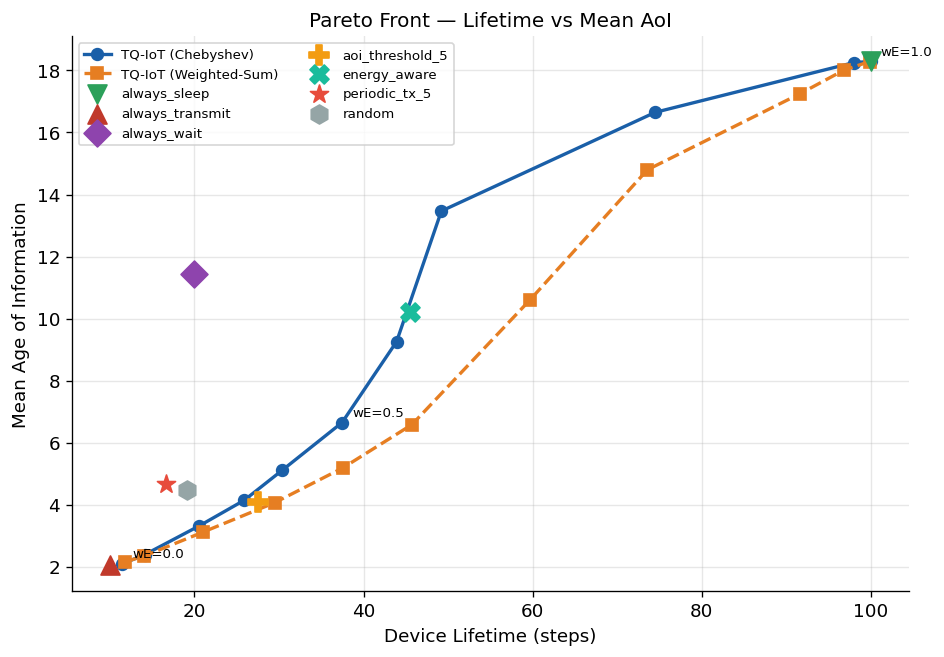

  Saved: 01_pareto_front.png


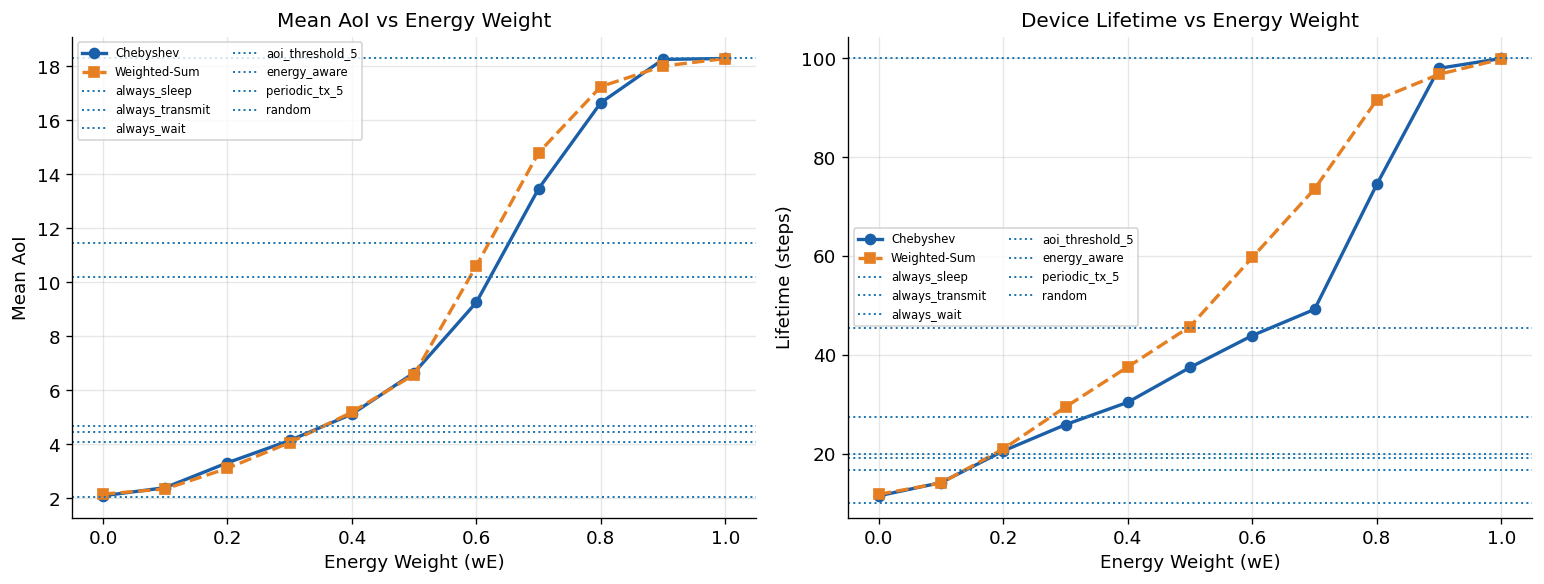

  Saved: 02_aoi_lifetime_vs_weight.png


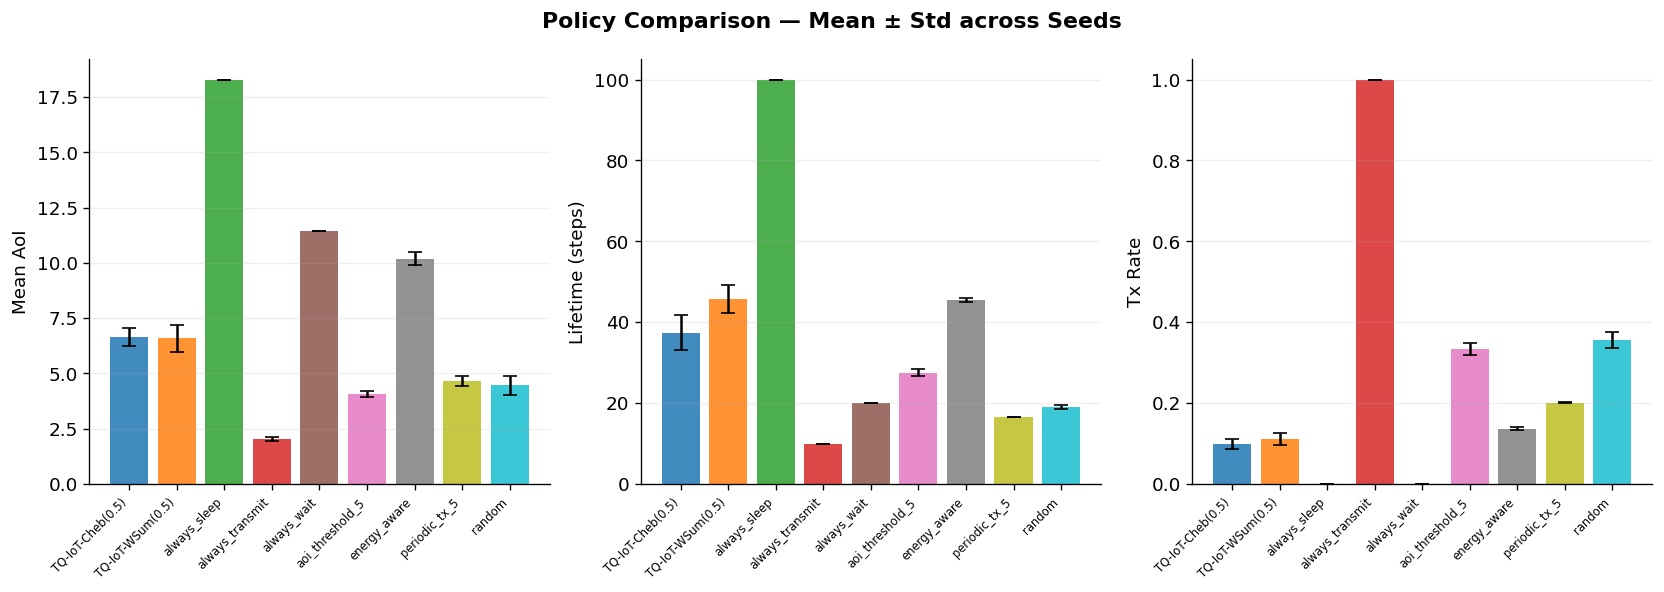

  Saved: 03_policy_comparison.png


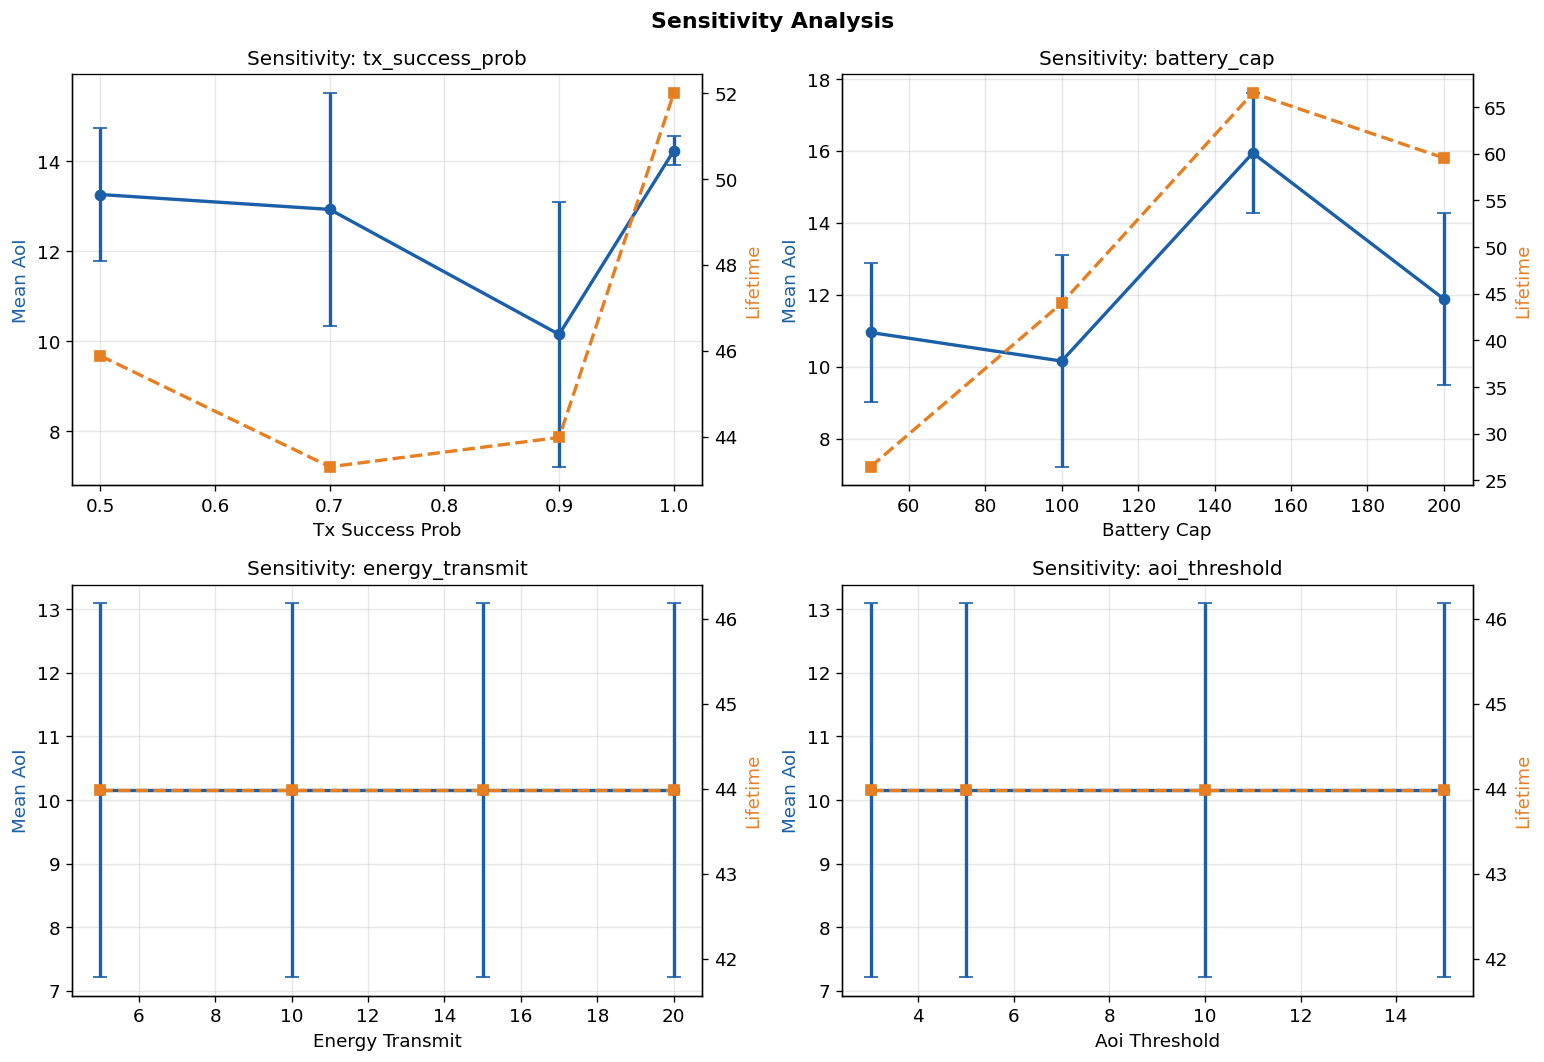

  Saved: 04_sensitivity.png


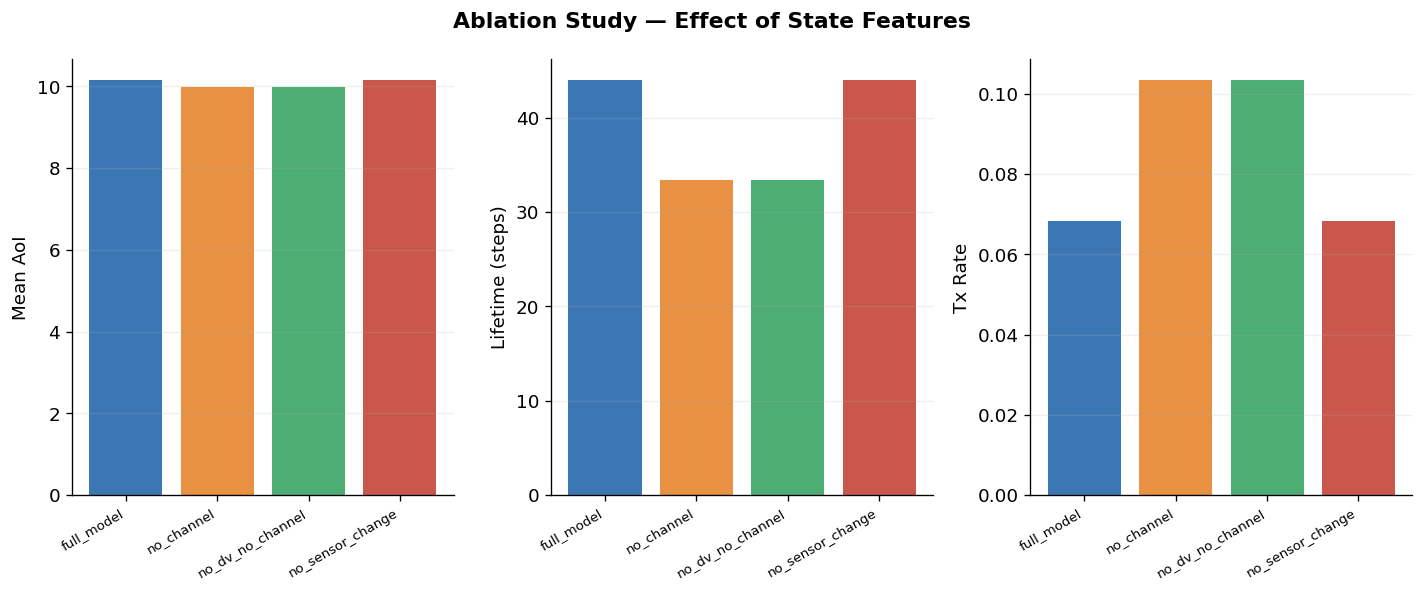

  Saved: 05_ablation.png


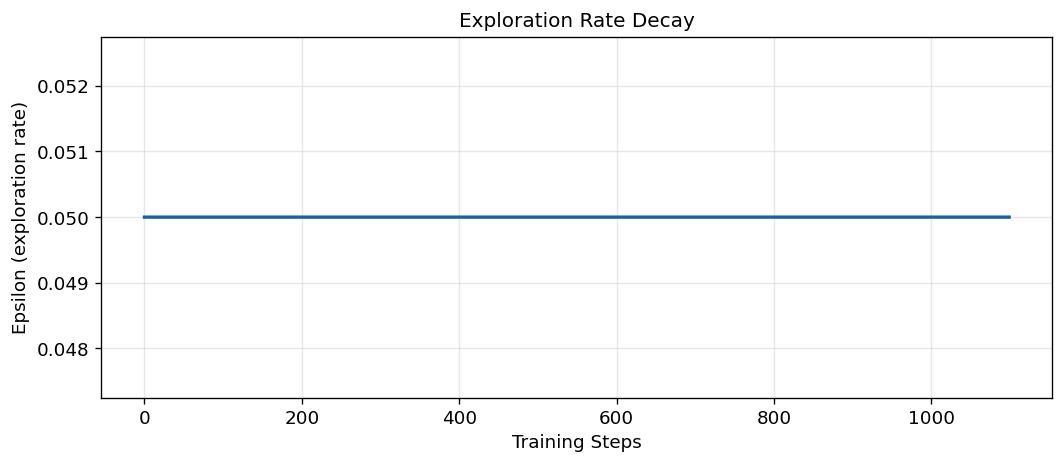

  Saved: 06_epsilon_decay.png


In [30]:
# helper
def save(name):
    p = FIGURES_DIR / f"{name}.png"
    plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Saved: {p.name}")

cheb_df  = all_df[all_df['method'] == 'chebyshev']
wsum_df  = all_df[all_df['method'] == 'weighted_sum']
base_sum = all_df[all_df['method'] == 'baseline'].groupby('policy').mean(numeric_only=True)

cheb_mean = cheb_df.groupby('wE').mean(numeric_only=True).reset_index()
wsum_mean = wsum_df.groupby('wE').mean(numeric_only=True).reset_index()

# ── 1. Pareto Front ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(cheb_mean['lifetime'], cheb_mean['mean_aoi'],
        'o-', color='#1a5fa8', lw=2, ms=7, label='TQ-IoT (Chebyshev)')
ax.plot(wsum_mean['lifetime'], wsum_mean['mean_aoi'],
        's--', color='#e67e22', lw=2, ms=7, label='TQ-IoT (Weighted-Sum)')

bl_colors  = ['#2ca05a','#c0392b','#8e44ad','#f39c12','#1abc9c','#e74c3c','#95a5a6']
bl_markers = ['v','^','D','P','X','*','h']
for (bl, row), col, mk in zip(base_sum.iterrows(), bl_colors, bl_markers):
    ax.scatter(row['lifetime'], row['mean_aoi'],
               marker=mk, s=130, color=col, zorder=4, label=bl)

for _, row in cheb_mean.iterrows():
    if row['wE'] in [0.0, 0.5, 1.0]:
        ax.annotate(f"wE={row['wE']:.1f}",
                    (row['lifetime'], row['mean_aoi']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.set_xlabel('Device Lifetime (steps)')
ax.set_ylabel('Mean Age of Information')
ax.set_title('Pareto Front — Lifetime vs Mean AoI')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
save("01_pareto_front")

# ── 2. AoI and Lifetime vs Weight ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(cheb_mean['wE'], cheb_mean['mean_aoi'],
         'o-', color='#1a5fa8', lw=2, ms=6, label='Chebyshev')
ax1.plot(wsum_mean['wE'], wsum_mean['mean_aoi'],
         's--', color='#e67e22', lw=2, ms=6, label='Weighted-Sum')
for bl, row in base_sum.iterrows():
    ax1.axhline(row['mean_aoi'], ls=':', lw=1.2, label=bl)
ax1.set_xlabel('Energy Weight (wE)')
ax1.set_ylabel('Mean AoI')
ax1.set_title('Mean AoI vs Energy Weight')
ax1.legend(fontsize=7, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.plot(cheb_mean['wE'], cheb_mean['lifetime'],
         'o-', color='#1a5fa8', lw=2, ms=6, label='Chebyshev')
ax2.plot(wsum_mean['wE'], wsum_mean['lifetime'],
         's--', color='#e67e22', lw=2, ms=6, label='Weighted-Sum')
for bl, row in base_sum.iterrows():
    ax2.axhline(row['lifetime'], ls=':', lw=1.2, label=bl)
ax2.set_xlabel('Energy Weight (wE)')
ax2.set_ylabel('Lifetime (steps)')
ax2.set_title('Device Lifetime vs Energy Weight')
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
save("02_aoi_lifetime_vs_weight")

# ── 3. Policy Comparison Bar Chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Policy Comparison — Mean ± Std across Seeds', fontweight='bold')

cheb_05  = cheb_df[cheb_df['wE'] == 0.5].groupby('policy')
wsum_05  = wsum_df[wsum_df['wE'] == 0.5].groupby('policy')

compare_policies = {
    'TQ-IoT-Cheb(0.5)': cheb_df[cheb_df['wE']==0.5][['mean_aoi','lifetime','tx_rate']],
    'TQ-IoT-WSum(0.5)': wsum_df[wsum_df['wE']==0.5][['mean_aoi','lifetime','tx_rate']],
}
for bl, row in base_sum.iterrows():
    compare_policies[bl] = all_df[all_df['policy']==bl][['mean_aoi','lifetime','tx_rate']]

names  = list(compare_policies.keys())
colors_bar = plt.cm.tab10(np.linspace(0, 1, len(names)))

for ax, metric, ylabel in zip(axes,
    ['mean_aoi', 'lifetime', 'tx_rate'],
    ['Mean AoI', 'Lifetime (steps)', 'Tx Rate']):
    means = [compare_policies[n][metric].mean() for n in names]
    stds  = [compare_policies[n][metric].std()  for n in names]
    bars  = ax.bar(range(len(names)), means, yerr=stds,
                   color=colors_bar, alpha=0.85, capsize=4, error_kw={'lw':1.5})
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.2, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
save("03_policy_comparison")

# ── 4. Sensitivity Analysis ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Sensitivity Analysis', fontweight='bold')
axes = axes.flatten()

for ax, param in zip(axes, sensitivity_params.keys()):
    sub = sens_df[sens_df['param'] == param].groupby('value').agg(
        aoi_mean=('mean_aoi','mean'), aoi_std=('mean_aoi','std'),
        lt_mean=('lifetime','mean')).reset_index()
    ax2 = ax.twinx()
    ax.errorbar(sub['value'], sub['aoi_mean'], yerr=sub['aoi_std'],
                color='#1a5fa8', marker='o', lw=2, capsize=4, label='Mean AoI')
    ax2.plot(sub['value'], sub['lt_mean'],
             color='#e67e22', marker='s', lw=2, ls='--', label='Lifetime')
    ax.set_xlabel(param.replace('_',' ').title())
    ax.set_ylabel('Mean AoI', color='#1a5fa8')
    ax2.set_ylabel('Lifetime', color='#e67e22')
    ax.set_title(f'Sensitivity: {param}')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)

plt.tight_layout()
save("04_sensitivity")

# ── 5. Ablation Study ─────────────────────────────────────────────────────────
abl_sum = abl_df.groupby('case').mean(numeric_only=True).reset_index()
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Ablation Study — Effect of State Features', fontweight='bold')
colors_abl = ['#1a5fa8','#e67e22','#2ca05a','#c0392b']

for ax, metric, ylabel in zip(axes,
    ['mean_aoi','lifetime','tx_rate'],
    ['Mean AoI','Lifetime (steps)','Tx Rate']):
    ax.bar(abl_sum['case'], abl_sum[metric],
           color=colors_abl, alpha=0.85)
    ax.set_xticks(range(len(abl_sum)))
    ax.set_xticklabels(abl_sum['case'], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.2, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
save("05_ablation")

# ── 6. Exploration Decay ─────────────────────────────────────────────────────
if epsilons_log:
    plt.figure(figsize=(9, 4))
    plt.plot(epsilons_log, lw=2, color='#1a5fa8')
    plt.xlabel('Training Steps')
    plt.ylabel('Epsilon (exploration rate)')
    plt.title('Exploration Rate Decay')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save("06_epsilon_decay")


## 15. Reproducibility Summary

In [31]:
generated_csvs = [f.name for f in RESULTS_DIR.glob("*.csv")]
generated_figs = [f.name for f in FIGURES_DIR.glob("*.png")]

print("=" * 60)
print("  EXPERIMENT SUMMARY")
print("=" * 60)
print(f"  Experiment ID       : {EXPERIMENT_ID}")
print(f"  Input folder        : {RAW_DATA_DIR}")
print(f"  Output folder       : {RESULTS_DIR}")
print(f"  Raw sensor records  : {len(raw_df):,}")
print(f"  Power records       : {len(power_df):,}" if not power_df.empty else "  Power records       : not available")
print(f"  Trace rows used     : {len(trace_df)}")
print(f"  Nodes               : {sorted(trace_df['node_id'].unique())}")
print(f"  Policies evaluated  : {all_df['policy'].nunique()}")
print(f"  Seeds used          : {SEEDS}")
print(f"  Weight configs      : {len(WEIGHTS)}")
print()
print(f"  Generated CSVs      :")
for f in sorted(generated_csvs): print(f"    {f}")
print(f"  Generated figures   :")
for f in sorted(generated_figs): print(f"    {f}")
print("=" * 60)


  EXPERIMENT SUMMARY
  Experiment ID       : 436032
  Input folder        : d:\thesis-iot-scheduling-\data\raw\exp_436032
  Output folder       : d:\thesis-iot-scheduling-\results\exp_436032
  Raw sensor records  : 2,505
  Power records       : 91,053
  Trace rows used     : 830
  Nodes               : ['m3-10', 'm3-11', 'm3-12', 'm3-13', 'm3-14']
  Policies evaluated  : 29
  Seeds used          : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Weight configs      : 11

  Generated CSVs      :
    ablation_results.csv
    cleaned_trace.csv
    metrics_all_seeds.csv
    metrics_summary.csv
    sensitivity_results.csv
  Generated figures   :
    01_pareto_front.png
    02_aoi_lifetime_vs_weight.png
    03_policy_comparison.png
    04_sensitivity.png
    05_ablation.png
    06_epsilon_decay.png
